### **Preparation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import os
import random

import numpy as np
from sklearn.preprocessing import StandardScaler
import geopandas as gpd

from spreg import GM_Combo, gets_sdm, GM_Lag
import libpysal
from spreg import OLS
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel
from esda.moran import Moran
from sklearn.feature_selection import mutual_info_classif
import libpysal
import matplotlib as mpl
import matplotlib.pyplot as plt
# !pip install torchmetrics
# from torchmetrics.functional.clustering import mutual_info_score

In [ ]:
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import os

font_path = "/content/drive/MyDrive/Arial.ttf"   # make sure this exists!

assert os.path.exists(font_path), "Arial.ttf not found!"

# 1. Register font
fm.fontManager.addfont(font_path)

# 2. Get the EXACT internal font name
arial_name = fm.FontProperties(fname=font_path).get_name()
print("Detected font name:", arial_name)

# 3. FORCE Matplotlib to use THIS font (not generic sans-serif)
mpl.rcParams.clear()   # <-- critical in Colab
mpl.rcParams.update({
    "font.family": arial_name,     # NOT 'sans-serif'
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# 4. Apply seaborn theme AFTER font setup
sns.set_theme(style="white")


Detected font name: Arial


In [ ]:
# Navigate to your project root (adjust this path as needed)
# After mounting, your Drive files will be in /content/drive/MyDrive
# You should set project_root to the specific folder within MyDrive where your project resides.
# This path *can* contain spaces, as you're navigating within the already mounted Drive.
project_root = '/content/drive/Othercomputers/My Mac/01_GeoTrans/Geo_Domain_Shift'

# Change the current working directory if you want relative paths to work from there
os.chdir(project_root)

print(f"Current working directory after changing: {os.getcwd()}")

# Now you can access your data, e.g., if it's in a 'data' folder within your project_root
# data_path = os.path.join(project_root, 'data')
# print(f"Path to data: {data_path}")

# If you just want to access it directly, without changing CWD:
# data_folder = '/content/drive/MyDrive/path/to/your/data'
# print(f"Data folder: {data_folder}")

Current working directory after changing: /content/drive/Othercomputers/My Mac/01_GeoTrans/Geo_Domain_Shift


In [ ]:
model = 'DGM_raw'

### **Read geographic data**

In [ ]:
us_county_geo_file = 'geo_data/tl_2018_us_county/tl_2018_us_county.shp'
gpd_us_county =  gpd.read_file(us_county_geo_file)
gpd_us_county = gpd_us_county [~gpd_us_county['STATEFP'].isin(['02','15','60','66','69','72','78'])]

In [ ]:
gpd_us_county = gpd_us_county.to_crs(epsg=26915)

In [ ]:
df_us_states = pd.read_csv("geo_data/us_states_fips.csv", dtype={"FIPS": str})

### **Plot data statistics map of Figure 1**

In [ ]:
areas = [area for area in os.listdir("data")]

In [ ]:
len(areas)

2265

In [ ]:
from collections import defaultdict

grouped = defaultdict(list)

for fips in areas:
    state_code = fips[:2]   # first two digits
    grouped[state_code].append(fips)

dict(grouped)

ct_num_list = []
for area in areas:
    if area == ".DS_Store":
          continue

    # demos = np.load(f"data/{area}/demos.npy")
    # pois = np.load(f"data/{area}/pois.npy")

    dis = np.load(f"data/{area}/dis.npy")
    ct_num_list.append(dis.shape[0])

df_county_count = pd.DataFrame(data= {'GEOID': areas, 'count': ct_num_list})

# df_county_count.to_csv('models/DGM_raw/evaluations/tables/dataset_statistics/county_census_tract_count.csv', index=False)

In [ ]:
df_county_count = pd.read_csv('models/{}/evaluations/tables/DGM_raw/county_census_tract_count.csv', dtype=({'GEOID': str}))

In [ ]:
gpd_us_county_ct_count = gpd_us_county.merge(df_county_count, on='GEOID')

In [ ]:
gpd_us_county_ct_count['log_count'] = np.log(gpd_us_county_ct_count['count'])

In [ ]:
us_state_geo_file = 'geo_data/tl_2024_us_state/tl_2024_us_state.shp'
gpd_us_state =  gpd.read_file(us_state_geo_file)
gpd_us_state['STATEFP'] = gpd_us_state['STATEFP'].astype(str)
gpd_us_state  = gpd_us_state [~gpd_us_state['STATEFP'].isin(['02','15','60','66','69','72','78'])]
gpd_us_state = gpd_us_state.to_crs(epsg=26915)

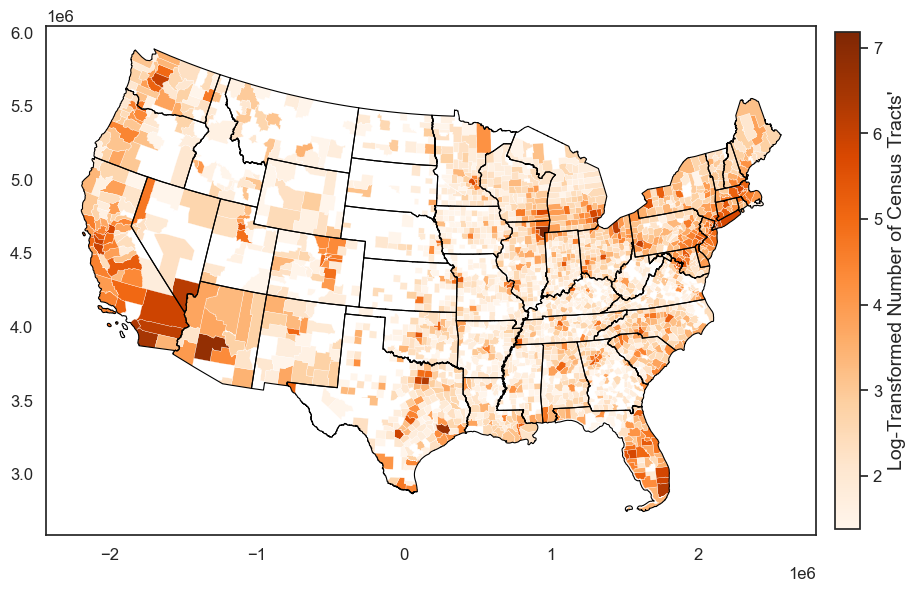

In [ ]:
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

ax = gpd_us_county_ct_count.plot(
    column="log_count",
    cmap="Oranges",
    legend=True,
    figsize=(10, 8),
    linewidth=0.2,
    # edgecolor="gray",
    legend_kwds={
        "shrink": 0.65,      # <<< KEY LINE (reduce height)
        "aspect": 20,       # thinner bar
        "pad": 0.02,
        "label": "Log-Transformed Number of Census Tracts'"
    },
)
gpd_us_state.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

plt.tight_layout()
# plt.savefig('models/{}/evaluations/figures/dataset_statistic.jpg'.format(model), bbox_inches='tight', dpi=300)
plt.show()

### **Read geographic domain shift indices and mobility prediction results**

In [ ]:
source_states = [['01'], ['04'], ['05'], ['06'], ['08'], ['09'],
 ['10'], ['12'], ['13'], ['16'], ['17'], ['18'], ['19'],
  ['20'], ['21'], ['22'], ['23'],['24'],['25'],['26'],['27'],['28'],['29'],
  ['30'],['31'],['32'],['33'],['34'],['35'],['36'],['37'],['38'],['39'],
  ['40'], ['41'], ['42'], ['44'],['45'],['46'],['47'],['48'],['49'],
  ['50'], ['51'], ['53'], ['54'], ['55'], ['56']]

In [ ]:
# import numpy as np
# import ast # Required for literal_eval

# src_tar_shift_list = []
# eval_results_list = []

# def nn_signed_diff(src_arr: np.ndarray, tar: float) -> float:
#     d = tar - src_arr                  # signed diffs to each source value
#     return d[np.argmin(np.abs(d))]     # nearest by abs, keep sign

# for train_states in source_states:
#     # states.append('+'.join(train_states))

#     test_states = list(set(df_us_states['FIPS']) - set(train_states))

#     df_domain_shift = pd.read_csv('models/DGM_raw/evaluations/domain_shift/by_source_state/{}_domain_shift.csv'.format('+'.join(train_states)),
#                                   dtype={"src_state": str, "tar_geoid": str})

#     df_domain_shift = df_domain_shift.rename(columns = {'moran_shift': 'moran_dis'})

#     df_domain_shift_v2 = pd.read_csv('models/DGM_raw/evaluations/domain_shift/by_source_state_moran/{}_domain_shift.csv'.format('+'.join(train_states)),
#                                   dtype={"src_state": str, "tar_geoid": str})

#     df_domain_shift_v2["src_moran"] = df_domain_shift_v2["src_moran"].apply(
#         lambda s: np.fromstring(str(s).strip("[]"), sep=" ")
#     )

#     df_domain_shift_v2["tar_moran"] = df_domain_shift_v2["tar_moran"].apply(
#         lambda s: np.fromstring(str(s).strip("[]"), sep=" ").item()
#     )

#     # df_domain_shift_v2["src_moran_std"]  = df_domain_shift_v2["src_moran"].apply(np.std)
#     # df_domain_shift_v2["src_moran_cv"]  = df_domain_shift_v2["src_moran"].apply(np.std) / df_domain_shift_v2["src_moran"].apply(np.mean)
#     df_domain_shift_v2["src_moran"] = df_domain_shift_v2["src_moran"].apply(np.mean)
#     df_domain_shift_v2["moran_mean"]  = df_domain_shift_v2["tar_moran"] - df_domain_shift_v2["src_moran"]

#     df_src_tar_shift = df_domain_shift.copy().merge(df_domain_shift_v2, on=['src_state', 'tar_geoid'], how='left')
#     # Set 'tar_geoid' as the index before appending to the list
#     # df_src_tar_shift = df_src_tar_shift.set_index('tar_geoid')

#     eval_results = pd.read_csv('models/DGM_raw/evaluations/tables/test/source_{}_county_level.csv'.format('+'.join(train_states)), dtype={"GEOID": str})
#     eval_results = eval_results[eval_results['GEOID'].str.startswith(tuple(test_states))]
#     eval_results['src_state'] = ['+'.join(train_states)] * eval_results.shape[0]
#     # avg_eval = eval_results.drop(columns = ['GEOID', 'num_regions'])

#     src_tar_shift_list.append(df_src_tar_shift)
#     eval_results_list.append(eval_results)

# df_src_tar_shifts = pd.concat(src_tar_shift_list)
# df_eval_results = pd.concat(eval_results_list, ignore_index=True)

In [ ]:
import numpy as np
import ast # Required for literal_eval

src_tar_shift_list = []
eval_results_list = []

def nn_signed_diff(src_arr: np.ndarray, tar: float) -> float:
    d = tar - src_arr                  # signed diffs to each source value
    return d[np.argmin(np.abs(d))]     # nearest by abs, keep sign

for train_states in source_states:
    # states.append('+'.join(train_states))

    test_states = list(set(df_us_states['FIPS']) - set(train_states))

    df_domain_shift_mi = pd.read_csv('models/DGM_raw/evaluations/domain_shift/by_source_state_mi/{}_domain_shift.csv'.format( '+'.join(train_states)),
                                  dtype={"src_state": str, "tar_geoid": str})

    # df_domain_shift_mi = df_domain_shift_mi.rename(columns = {'moran_shift': 'moran_dis'})
    df_domain_shift_mi.drop('moran_shift', axis=1, inplace=True)

    df_domain_shift_moran = pd.read_csv('models/DGM_raw/evaluations/domain_shift/by_source_state_moran/{}_domain_shift.csv'.format('+'.join(train_states)),
                                  dtype={"src_state": str, "tar_geoid": str})

    df_domain_shift_moran ["src_moran"] = df_domain_shift_moran ["src_moran"].apply(
        lambda s: np.fromstring(str(s).strip("[]"), sep=" ")
    )

    df_domain_shift_moran ["tar_moran"] = df_domain_shift_moran ["tar_moran"].apply(
        lambda s: np.fromstring(str(s).strip("[]"), sep=" ").item()
    )

    df_domain_shift_moran ["src_moran"] = df_domain_shift_moran ["src_moran"].apply(np.mean)
    df_domain_shift_moran ["moran_mean"]  = df_domain_shift_moran ["tar_moran"] - df_domain_shift_moran["src_moran"]

    df_src_tar_shift = df_domain_shift_mi.copy().merge(df_domain_shift_moran, on=['src_state', 'tar_geoid'], how='left')

    eval_results = pd.read_csv('models/DGM_raw/evaluations/tables/test/source_{}_county_level.csv'.format('+'.join(train_states)), dtype={"GEOID": str})
    eval_results = eval_results[eval_results['GEOID'].str.startswith(tuple(test_states))]
    eval_results['src_state'] = ['+'.join(train_states)] * eval_results.shape[0]
    src_tar_shift_list.append(df_src_tar_shift)
    eval_results_list.append(eval_results)

df_src_tar_shifts = pd.concat(src_tar_shift_list)
df_eval_results = pd.concat(eval_results_list, ignore_index=True)

In [ ]:
df_src_tar_shifts.head()

,src_state,tar_geoid,mi_shift,moran_dis,src_moran,tar_moran,moran_shift,moran_mean
0,01,34019,0.005807,0.598117,-0.138971,-0.048992,0.735440,0.089979
1,01,34021,0.005986,0.612300,-0.138971,-0.020201,0.970759,0.118769
2,01,34023,0.012534,0.458720,-0.138971,0.000186,1.137393,0.139156
3,01,34025,0.010486,0.303676,-0.138971,0.001393,1.147266,0.140364
4,01,34027,0.014391,0.400327,-0.138971,0.007048,1.193486,0.146019


In [ ]:
top_src_states = df_src_tar_shifts.sort_values(by='src_moran', ascending=False)['src_state'].unique()

display(top_src_states[:3])

array(['44', '09', '34'], dtype=object)

In [ ]:
top_src_states = df_src_tar_shifts.sort_values(by='src_moran')['src_state'].unique()

display(top_src_states[:3])

array(['56', '46', '05'], dtype=object)

In [ ]:
df_analysis = pd.merge(df_eval_results, df_src_tar_shifts, left_on=['src_state', 'GEOID'], right_on=['src_state', 'tar_geoid'])
nan_counts = df_analysis.isna().sum()
print("Columns with NaN values:")
print(nan_counts[nan_counts > 0])

# Optional: Display rows with NaN values for inspection
rows_with_nan = df_analysis[df_analysis.isna().any(axis=1)]
if not rows_with_nan.empty:
    print("\nFirst 5 rows with NaN values:")
    display(rows_with_nan.head())

if 'GEOID' in df_analysis.columns:
    df_analysis = df_analysis.drop(columns=['GEOID'])

Columns with NaN values:
Series([], dtype: int64)


In [ ]:
df_analysis.head()

,num_regions,RMSE,NRMSE,MAE,MAPE,SMAPE,CPC,RMSE_nonzero,MAE_nonzero,MAPE_nonzero,...,JSD_outflow,JSD_ODflow,src_state,tar_geoid,mi_shift,moran_dis,src_moran,tar_moran,moran_shift,moran_mean
0,5,97.964295,0.757932,65.243462,1.246725,0.705896,0.741321,97.964295,65.243462,1.246725,...,0.236453,0.077420,01,48123,0.001277,1.188860,-0.138971,-0.277552,-1.132696,-0.138582
1,145,10.530494,0.956345,4.286206,1.553835,1.232150,0.494258,13.149318,5.270419,0.798010,...,0.287135,0.090579,01,13089,0.012784,0.413619,-0.138971,-0.004990,1.095093,0.133981
2,8,49.194933,0.542694,34.747508,1.217087,0.616426,0.811497,49.573307,35.170345,1.107695,...,0.218995,0.079028,01,20099,0.001614,1.084225,-0.138971,-0.150591,-0.094980,-0.011621
3,15,146.793135,0.979826,87.313129,2.274502,0.828714,0.586300,146.793135,87.313129,2.274502,...,0.070105,0.159124,01,18005,0.002462,0.660884,-0.138971,-0.127673,0.092339,0.011297
4,7,38.969895,0.645656,30.072314,0.560167,0.435769,0.835608,38.969895,30.072314,0.560167,...,0.160112,0.101661,01,19123,0.001632,1.072762,-0.138971,-0.232766,-0.766638,-0.093796


In [ ]:
df_analysis['tar_state'] = df_analysis['tar_geoid'].str[:2]

In [ ]:
df_analysis_src_tar = df_analysis.drop(columns=['tar_geoid']).groupby(['src_state', 'tar_state']).agg(['mean'])

In [ ]:
df_analysis_src_tar.columns = ['_'.join(col) for col in df_analysis_src_tar.columns]

### **Plot asymmetry map of Figure 2**

In [ ]:
df_us_states.head()

,State,Code,FIPS
0,Alabama,AL,01
1,Alaska,AK,02
2,Arizona,AZ,04
3,Arkansas,AR,05
4,California,CA,06


In [ ]:
CPC_matrix = (
    df_analysis
    .drop(columns=['num_regions', 'tar_geoid'])
    .pivot_table(
        index='src_state',
        columns='tar_state',
        values='CPC',
        aggfunc='mean'
    )
)

In [ ]:
CPC_matrix.index = CPC_matrix.index.map(lambda x: df_us_states.set_index('FIPS')['Code'].to_dict().get(x, x))
CPC_matrix.columns = CPC_matrix.columns.map(lambda x: df_us_states.set_index('FIPS')['Code'].to_dict().get(x, x))

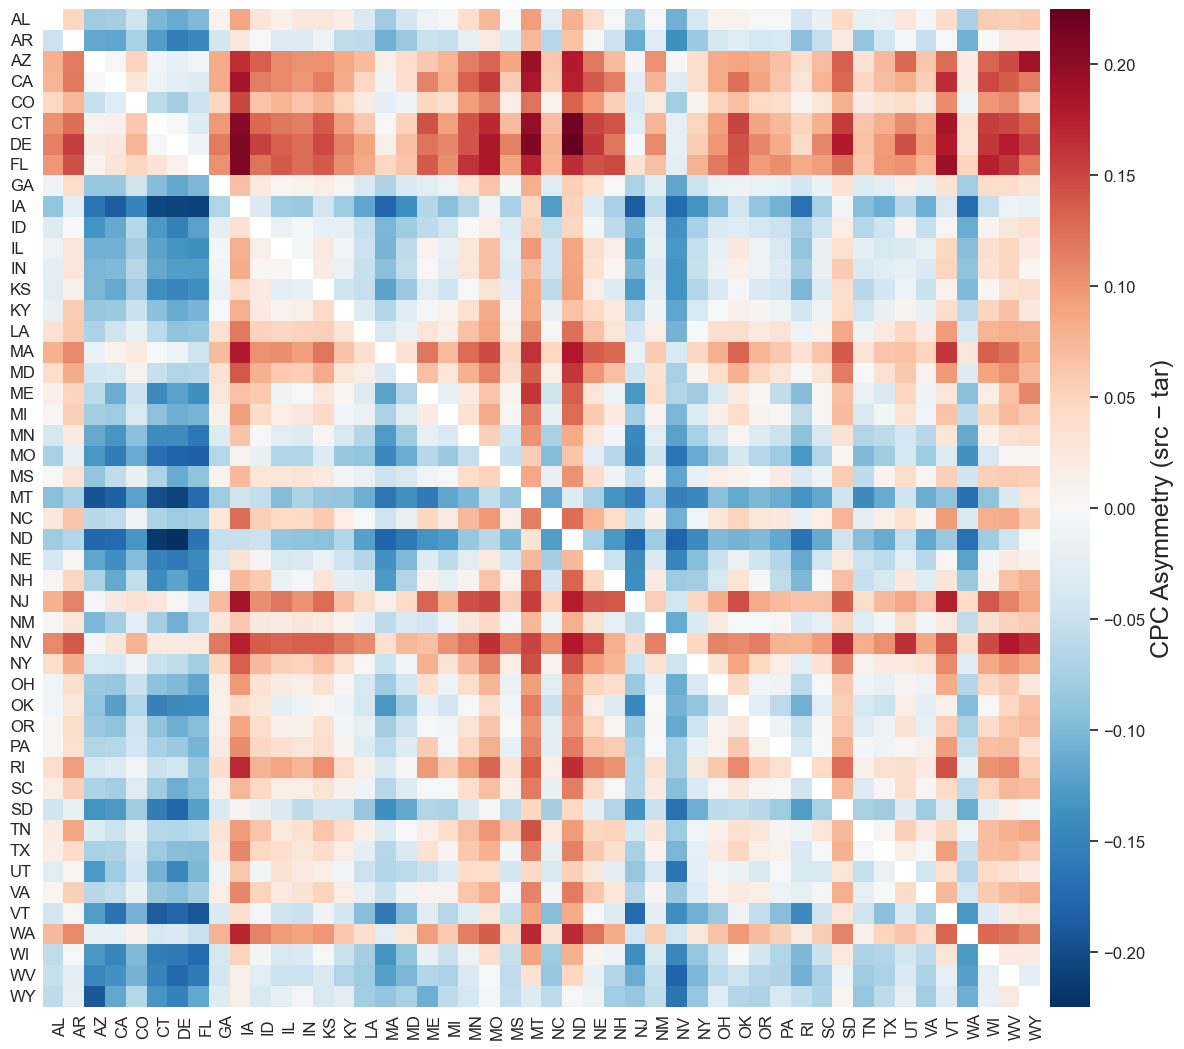

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 18,
    "pdf.fonttype": 42,
})



from mpl_toolkits.axes_grid1 import make_axes_locatable

# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="4%", pad=0.1)

A = CPC_matrix - CPC_matrix.T
A = A.dropna(axis=0, how='all').dropna(axis=1, how='all')

# mask = np.tril(np.ones_like(A, dtype=bool))  # mask lower + diagonal
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 18,
    "pdf.fonttype": 42,
})

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 12))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.1)

sns.heatmap(
    A,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    square=True,
    cbar=True,
    cbar_ax=cax,
    cbar_kws={'label': 'CPC Asymmetry (src − tar)'}
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    va="top",
    rotation_mode="anchor"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    va="center",
    ha="left"
)
ax.tick_params(axis="y", length=20)
ax.tick_params(axis="x", length=10)

plt.tight_layout()
# plt.savefig('models/{}/evaluations/figures/CPC_matrix.pdf'.format(model), bbox_inches='tight')

In [ ]:
RMSE_matrix = (
    df_analysis
    .pivot_table(
        index='src_state',
        columns='tar_state',
        values='RMSE',
        aggfunc='mean'
    )
)
# RMSE_norm = (RMSE_matrix - RMSE_matrix.min().min()) / (
#     RMSE_matrix.max().max() - RMSE_matrix.min().min()
# )
RMSE_norm = RMSE_matrix.copy()

In [ ]:
RMSE_norm.index = RMSE_norm.index.map(lambda x: df_us_states.set_index('FIPS')['Code'].to_dict().get(x, x))
RMSE_norm.columns = RMSE_norm.columns.map(lambda x: df_us_states.set_index('FIPS')['Code'].to_dict().get(x, x))

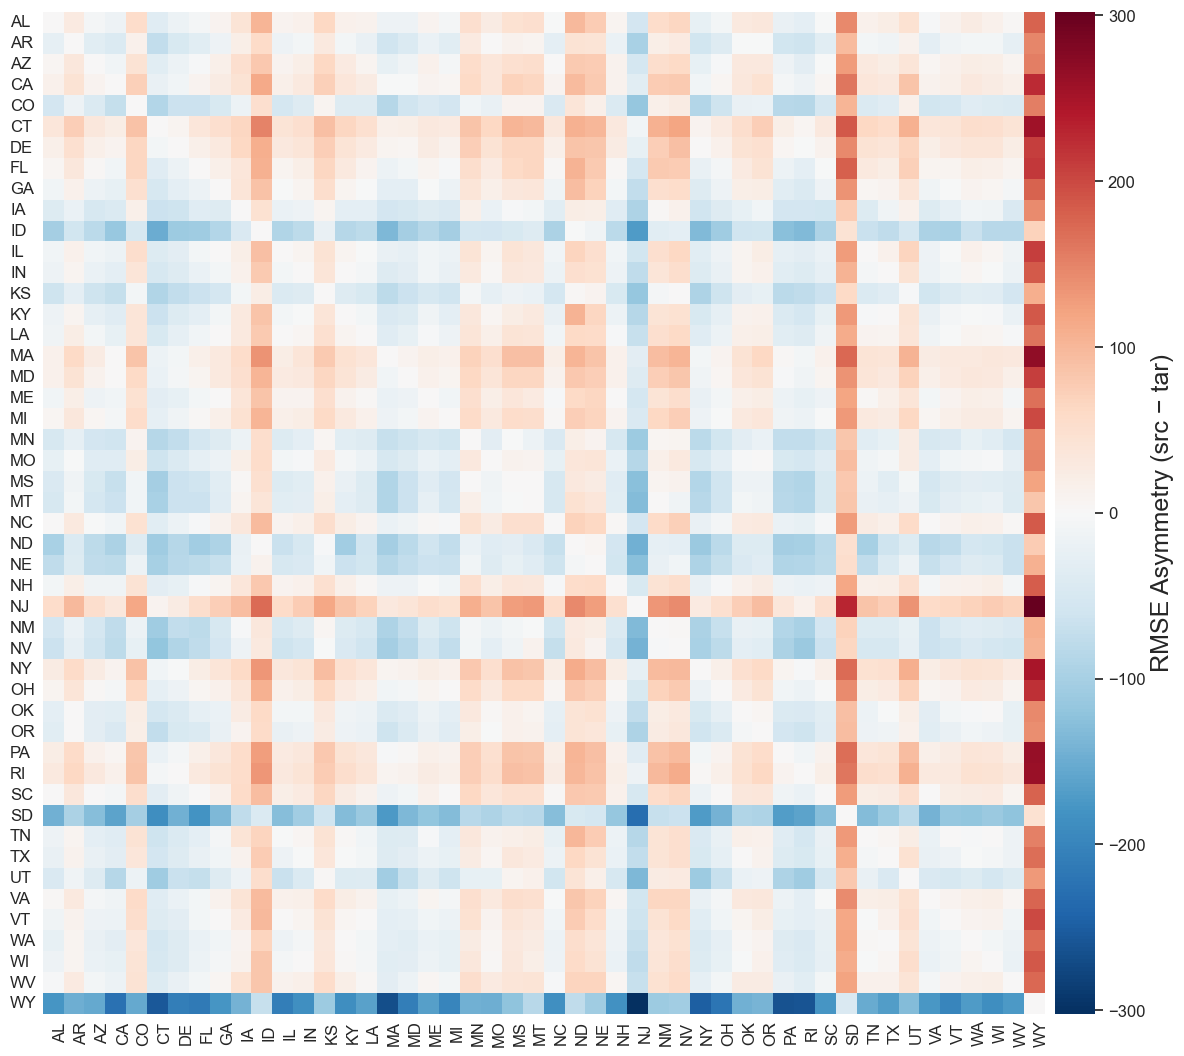

In [ ]:
A_rmse = RMSE_norm - RMSE_norm.T
A_rmse = A_rmse.dropna(axis=0, how='all').dropna(axis=1, how='all')
for k in A_rmse.index.intersection(A_rmse.columns):
    A_rmse.loc[k, k] = 0

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 18,
    "pdf.fonttype": 42,
})

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 12))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.1)

sns.heatmap(
    A_rmse,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    square=True,
    cbar=True,
    cbar_ax=cax,
    cbar_kws={'label': 'RMSE Asymmetry (src − tar)'}
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    va="top",
    rotation_mode="anchor"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    va="center",
    ha="left"
)
ax.tick_params(axis="y", length=20)
ax.tick_params(axis="x", length=10)

plt.tight_layout()
# plt.savefig('models/{}/evaluations/figures/RMSE_matrix.pdf'.format(model), bbox_inches='tight')

### **Plot Figure 3**

#### Geographic domain shift joint distribution

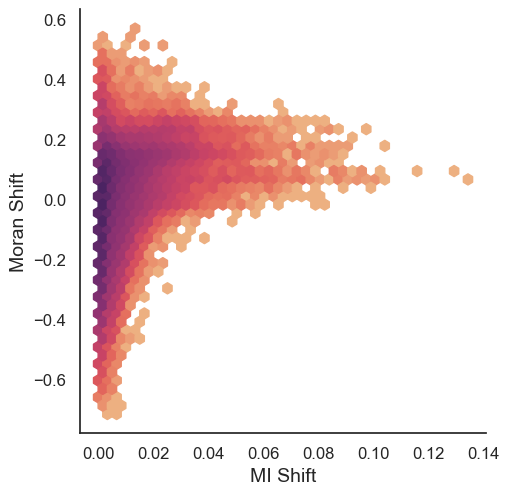

In [ ]:
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt # Import pyplot for figure adjustments

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

plt.close("all")

width_in_inches = 8 # Set your desired width
height_in_inches = 6 # Set your desired height

g = sns.jointplot(
    data=df_analysis,
    x="mi_shift",
    # y="moran_shift",
    y="moran_mean",
    kind="hex",
    gridsize=40,
    mincnt=1,
    cmap="flare",
    height=height_in_inches, # Keep height for initial square sizing
    # marginal_ticks=True
)

# remove marginals
g.ax_marg_x.remove()
g.ax_marg_y.remove()

# Adjust the figure size after creation to make it wider
# g.fig.set_size_inches(width_in_inches, height_in_inches)

for p in g.ax_marg_x.patches + g.ax_marg_y.patches:
    p.set_facecolor("#BDBDBD")
    p.set_edgecolor("none")

# Access the hexbin artist
hb = g.ax_joint.collections[0]

# Apply log normalization to counts
hb.set_norm(mcolors.LogNorm())

# Update colorbar
# cbar = g.fig.colorbar(hb, ax=g.ax_joint)
# cbar.set_label("log10(Count)")
g.set_axis_labels("MI Shift", "Moran Shift")

plt.tight_layout()
# plt.savefig('models/{}/evaluations/figures/geoshift_distribution.pdf'.format(model), bbox_inches='tight')
# plt.savefig('models/{}/evaluations/figures/geoshift_distribution.jpg'.format(model), bbox_inches='tight', dpi=300)
plt.show()

 #### MI quantile cases

In [ ]:
df_analysis_agg_tar = df_analysis.drop(columns = ['num_regions', 'src_state', 'tar_state', 'src_moran']).groupby('tar_geoid').agg(['mean'])
df_analysis_agg_tar.columns = ['_'.join(col) for col in df_analysis_agg_tar.columns]

In [ ]:
# close old figures so you don't see stale outputs

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,
})

plt.close("all")

In [ ]:
# Calculate the quantiles again to ensure we have them for this step
quantiles_mi_shift = df_analysis_agg_tar['mi_shift_mean'].quantile([0.25, 0.5, 0.75])

print("Tar_GEOID and their MI Shift Mean closest to the 25th, 50th, and 75th percentiles:")

results = []
for percentile, q_value in quantiles_mi_shift.items():
    # Find the tar_geoid with mi_shift_mean closest to the quantile value
    closest_geoid = (df_analysis_agg_tar['mi_shift_mean'] - q_value).abs().idxmin()
    closest_row = df_analysis_agg_tar.loc[closest_geoid]

    results.append({
        'percentile': percentile,
        'quantile_value': q_value,
        'closest_tar_geoid': closest_geoid,
        'mi_shift_mean': closest_row['mi_shift_mean'],
        'moran_shift_mean': closest_row['moran_shift_mean']
    })

df_quantile_geoids = pd.DataFrame(results)
display(df_quantile_geoids)

Tar_GEOID and their MI Shift Mean closest to the 25th, 50th, and 75th percentiles:


,percentile,quantile_value,closest_tar_geoid,mi_shift_mean,moran_shift_mean
0,0.25,0.002899,05113,0.002900,-1.798310
1,0.50,0.004269,49045,0.004271,-0.536966
2,0.75,0.007024,19163,0.007023,1.400827


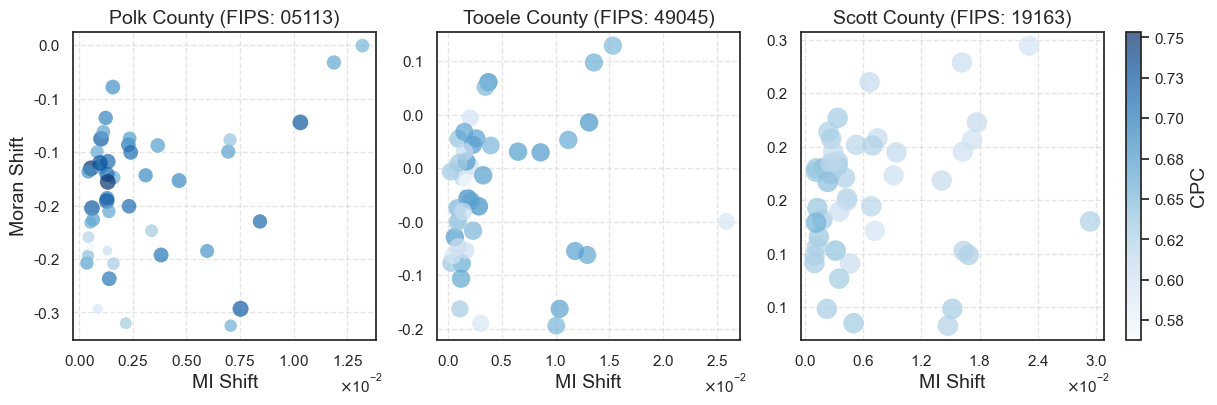

In [ ]:
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.ticker import ScalarFormatter

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
fmt.format = lambda x, pos: f"{x:.2e}"


sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

plt.close("all")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(right=0.90)          # <-- key

df_analysis_scale = df_analysis[df_analysis['tar_geoid'].isin(['05113', '49045', '19163'])]

global_rmse_min, global_rmse_max = df_analysis_scale['RMSE'].min(), df_analysis_scale['RMSE'].max()
def rmse_to_size(rmse, s_min=40, s_max=220):
    # smaller RMSE -> bigger points (your intention: 1 - normalized RMSE)
    t = 1 - (rmse - global_rmse_min) / (global_rmse_max - global_rmse_min + 1e-12)
    return s_min + t * (s_max - s_min)

global_cpc_min = df_analysis_scale['CPC'].min()
global_cpc_max = df_analysis_scale['CPC'].max()

size = 1 - (df_analysis_scale['RMSE'] - df_analysis_scale['RMSE'].min()) / (df_analysis_scale['RMSE'].max() - df_analysis_scale['RMSE'].min())
# Subplot 1: MI Shift vs CPC
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '05113']
sc1 = axes[0].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Blues', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220))
# sc1 = axes[0].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:blue', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc1, ax=axes[0], label='CPC')
axes[0].set_xlabel('MI Shift')
axes[0].set_ylabel('Moran Shift')
axes[0].set_title('Polk County (FIPS: 05113)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Subplot 2: MI Shift vs RMSE
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '49045']
sc2 = axes[1].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Blues', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220)) # Oranges_r for reverse color map
# sc2 = axes[1].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:pink', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc2, ax=axes[1], label='RMSE')
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[1].set_xlabel('MI Shift')
axes[1].set_ylabel('Moran Shift')
axes[1].set_title('Tooele County (FIPS: 49045)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))

# Subplot 3: MI Shift vs RMSE
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '19163']
sc3 = axes[2].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Blues', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220)) # Oranges_r for reverse color map
# sc3 = axes[2].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:pink', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc3, ax=axes[2], label='CPC')
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[2].set_xlabel('MI Shift')
axes[2].set_ylabel('Moran Shift')
axes[2].set_title('Scott County (FIPS: 19163)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=6))

for ax in axes:
    ax.xaxis.set_major_formatter(fmt)
    offset = ax.xaxis.get_offset_text()
    offset.set_x(1.02)
    offset.set_y(-0.15)

pos = axes[-1].get_position()

cbar = fig.colorbar(sc3, ax=axes, pad=0.02, fraction=0.03)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.set_label("CPC")

axes[0].set_ylabel("Moran Shift")
for ax in axes[1:]:
    ax.set_ylabel("")
# plt.tight_layout()

# plt.savefig('models/{}/evaluations/figures/mi_quantile.pdf'.format(model), bbox_inches='tight')
plt.show()

#### Visualize Moran quantile cases

In [ ]:
# Calculate the quantiles again to ensure we have them for this step
quantiles_moran_shift = df_analysis_agg_tar['moran_shift_mean'].quantile([0.25, 0.5, 0.75])

print("Tar_GEOID and their MI Shift Mean closest to the 25th, 50th, and 75th percentiles:")

results = []
for percentile, q_value in quantiles_moran_shift.items():
    # Find the tar_geoid with mi_shift_mean closest to the quantile value
    closest_geoid = (df_analysis_agg_tar['moran_shift_mean'] - q_value).abs().idxmin()
    closest_row = df_analysis_agg_tar.loc[closest_geoid]

    results.append({
        'percentile': percentile,
        'quantile_value': q_value,
        'closest_tar_geoid': closest_geoid,
        'mi_shift_mean': closest_row['mi_shift_mean'],
        'moran_shift_mean': closest_row['moran_shift_mean']
    })

df_quantile_geoids = pd.DataFrame(results)
display(df_quantile_geoids)

Tar_GEOID and their MI Shift Mean closest to the 25th, 50th, and 75th percentiles:


,percentile,quantile_value,closest_tar_geoid,mi_shift_mean,moran_shift_mean
0,0.25,-1.321110,13055,0.002927,-1.320541
1,0.50,-0.171245,18177,0.005114,-0.171741
2,0.75,0.701996,12115,0.037422,0.701895


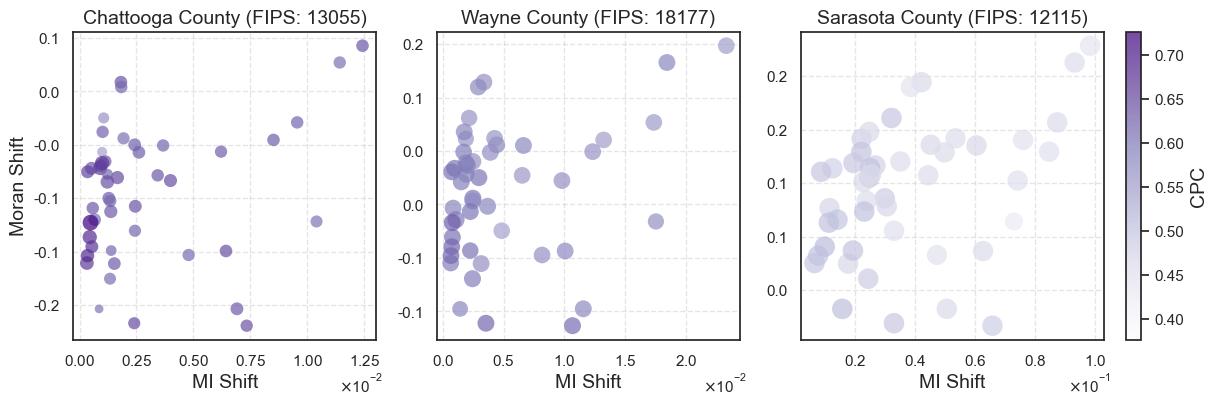

In [ ]:
from matplotlib.ticker import FuncFormatter, MaxNLocator

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
fmt.format = lambda x, pos: f"{x:.2e}"

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

plt.close("all")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(right=0.90)          # <-- key

df_analysis_scale = df_analysis[df_analysis['tar_geoid'].isin(['13055', '18177', '12115'])]

global_rmse_min, global_rmse_max = df_analysis_scale['RMSE'].min(), df_analysis_scale['RMSE'].max()
def rmse_to_size(rmse, s_min=40, s_max=220):
    # smaller RMSE -> bigger points (your intention: 1 - normalized RMSE)
    t = 1 - (rmse - global_rmse_min) / (global_rmse_max - global_rmse_min + 1e-12)
    return s_min + t * (s_max - s_min)

global_cpc_min = df_analysis_scale['CPC'].min() - 0.05
global_cpc_max = df_analysis_scale['CPC'].max()

size = 1 - (df_analysis_scale['RMSE'] - df_analysis_scale['RMSE'].min()) / (df_analysis_scale['RMSE'].max() - df_analysis_scale['RMSE'].min())
# Subplot 1: MI Shift vs CPC
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '13055']
sc1 = axes[0].scatter(df_analysis_same_tar['mi_shift'],df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Purples', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220))
# sc1 = axes[0].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:blue', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc1, ax=axes[0], label='CPC')
# axes[0].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[0].set_xlabel('MI Shift')
axes[0].set_ylabel('Moran Shift')
axes[0].set_title('Chattooga County (FIPS: 13055)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))

# Subplot 2: MI Shift vs RMSE
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '18177']
sc2 = axes[1].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Purples', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220)) # Oranges_r for reverse color map
# sc2 = axes[1].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:pink', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc2, ax=axes[1], label='RMSE')
# axes[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[1].set_xlabel('MI Shift')
axes[1].set_ylabel('Moran Shift')
axes[1].set_title('Wayne County (FIPS: 18177)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))

# Subplot 3: MI Shift vs RMSE
df_analysis_same_tar = df_analysis[df_analysis['tar_geoid'] == '12115']
sc3 = axes[2].scatter(df_analysis_same_tar['mi_shift'],  df_analysis_same_tar['moran_mean'],
                      c=df_analysis_same_tar['CPC'], cmap='Purples', alpha=0.7, edgecolors='none', vmin=global_cpc_min, vmax=global_cpc_max,
                      s=rmse_to_size(df_analysis_same_tar['RMSE'], s_min=40, s_max=220)) # Oranges_r for reverse color map
# sc3 = axes[2].scatter(df_analysis_same_tar['mi_shift'], df_analysis_same_tar['moran_shift'], color='tab:pink', alpha=0.7, edgecolors='none', s=150)
# fig.colorbar(sc3, ax=axes[2], label='CPC')
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[2].set_xlabel('MI Shift')
axes[2].set_ylabel('Moran Shift')
axes[2].set_title('Sarasota County (FIPS: 12115)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=6))

for ax in axes:
    ax.xaxis.set_major_formatter(fmt)
    offset = ax.xaxis.get_offset_text()
    offset.set_x(1.02)
    offset.set_y(-0.15)

pos = axes[-1].get_position()

# [left, bottom, width, height]
# cax = fig.add_axes([
#     pos.x1 + 0.02,   # just to the right
#     pos.y0,          # same bottom
#     0.02,            # width
#     pos.height       # same height
# ])
# cbar = fig.colorbar(sc3, cax=cax)
# cbar.set_label("CPC")
cbar = fig.colorbar(sc3, ax=axes, pad=0.02, fraction=0.03)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.set_label("CPC")
axes[0].set_ylabel("Moran Shift")
for ax in axes[1:]:
    ax.set_ylabel("")
# plt.tight_layout()

plt.savefig('models/{}/evaluations/figures/moran_quantile.pdf'.format(model), bbox_inches='tight')
plt.show()

### **Table 2 and Figure 4: Linear mixed-effects analysis**

In [ ]:
import statsmodels.formula.api as smf

df_analysis_copy = df_analysis.copy()
# df_analysis_copy['log_rmse'] = df_analysis_copy['RMSE'].apply(np.log1p)
feat_scaler = StandardScaler()

predictors = ['mi_shift', 'moran_shift']
df_analysis_copy[predictors] = feat_scaler.fit_transform(df_analysis_copy[predictors])
# df_analysis_copy['src_moran_cv'] = df_analysis_copy['src_moran_cv'].apply(np.abs)
#
df_analysis_copy['logit_CPC'] = np.log(df_analysis_copy['CPC'] / (1 - df_analysis_copy['CPC']))
m = smf.mixedlm(
    # "log_rmse ~ mi_shift + moran_shift + src_moran",
    "logit_CPC ~ mi_shift + moran_shift + C(src_state, Treatment(reference='01'))",
    data=df_analysis_copy,
    groups=df_analysis["tar_geoid"]
).fit(reml=True)

print(m.summary())


                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            logit_CPC 
No. Observations:            105845             Method:                        REML      
No. Groups:                  2252               Scale:                         0.0244    
Min. group size:             47                 Log-Likelihood:                39395.2371
Max. group size:             48                 Converged:                     Yes       
Mean group size:             47.0                                                        
-----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      0.572    0.010  57.777 0.000  0.553  0.591
C(src_state, Treatment(reference='01

In [ ]:
import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

def joint_partial_heatmap(
    df,
    result,
    mi_col="mi_shift",
    moran_col="moran_shift",
    state_col="src_state",
    rhs="C(src_state) + mi_shift + moran_shift",  # MUST match your MixedLM fixed-effects RHS
    n_grid=60,
    use_state="mode",   # "mode" or specify a value like "CA" / 04 etc.
    q_low=0.05,
    q_high=0.95,
    cmap="viridis"
):
    # --- 1) Choose ranges (avoid extreme tails) ---
    mi_grid = np.linspace(df[mi_col].quantile(q_low), df[mi_col].quantile(q_high), n_grid)
    moran_grid = np.linspace(df[moran_col].quantile(q_low), df[moran_col].quantile(q_high), n_grid)
    MI, MORAN = np.meshgrid(mi_grid, moran_grid)

    # --- 2) Pick a reference training state for the fixed effects ---
    if use_state == "mode":
        ref_state = df[state_col].mode()[0]
    else:
        ref_state = use_state

    # Force category levels to match training data (important for C(src_state))
    src_cats = pd.Categorical(df[state_col]).categories

    pred_df = pd.DataFrame({
        mi_col: MI.ravel(),
        moran_col: MORAN.ravel(),
        state_col: pd.Categorical([ref_state] * MI.size, categories=src_cats)
    })

    # --- 3) Build X using the SAME columns as the fitted model ---
    X_pred = patsy.dmatrix(rhs, pred_df, return_type="dataframe")

    beta = result.fe_params  # pandas Series
    X_pred = X_pred.reindex(columns=beta.index, fill_value=0.0)  # align exactly

    Z = (X_pred.to_numpy() @ beta.to_numpy()).reshape(MI.shape)

    # --- 4) Plot (heatmap style) ---
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        Z,
        cmap=cmap,
        cbar_kws={"label": "Predicted CPC (fixed effects only)"}
    )

    # Make axes readable (don’t label every grid point)
    xticks = np.linspace(0, n_grid - 1, 6).astype(int)
    yticks = np.linspace(0, n_grid - 1, 6).astype(int)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([f"{mi_grid[i]:.2f}" for i in xticks], rotation=0)
    ax.set_yticklabels([f"{moran_grid[i]:.2f}" for i in yticks], rotation=0)

    ax.set_xlabel("MI Shift")
    ax.set_ylabel("Moran Shift")
    # ax.set_title("Joint partial effect of MI Shift and Moran Shift (MixedLM)")

    ax.invert_yaxis()
    plt.tight_layout()
    # plt.savefig('models/{}/evaluations/figures/Joint_partial_effects_CPC.pdf'.format(model), bbox_inches='tight')
    plt.show()

    return MI, MORAN, Z


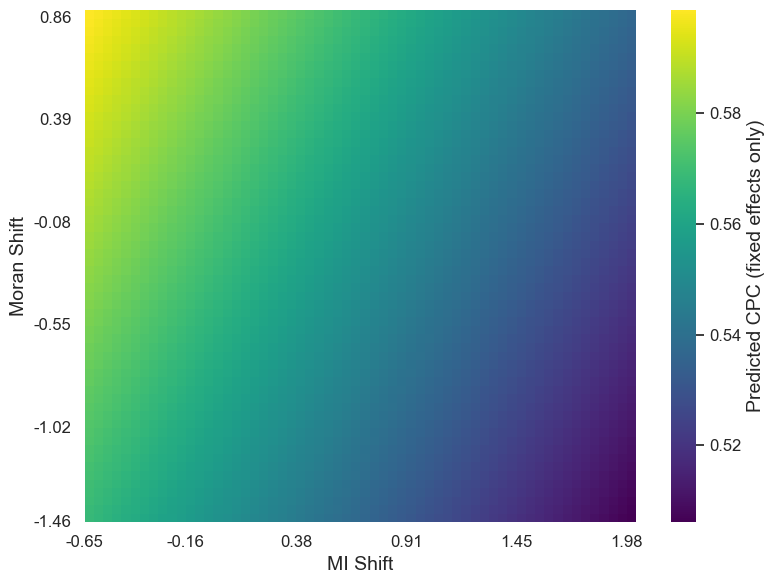

In [ ]:
MI, MORAN, Z = joint_partial_heatmap(df_analysis_copy, m)


In [ ]:
fe = m.fe_params
se = m.bse_fe

state_terms = fe.index[fe.index.str.startswith("C(src_state, Treatment(reference='01'))[T.")]
df_state = pd.DataFrame({
    "term": state_terms,
    "coef": fe.loc[state_terms].values,
    "se": se.loc[state_terms].values
})

# Extract FIPS code
df_state["state_fips"] = df_state["term"].str.extract(r"\[T\.(.*)\]")


In [ ]:
ref_state = '01'

df_ref = pd.DataFrame({
    "state_fips": [ref_state],
    "coef": [0.0],
    "se": [np.nan]
})

df_state = pd.concat([df_state[["state_fips","coef","se"]], df_ref], ignore_index=True)


In [ ]:
states_fe = gpd_us_state.merge(
    df_state,
    left_on="STATEFP",
    right_on="state_fips",
    how="left"
)

states_fe["sig"] = states_fe["coef"].abs() > 1.96 * states_fe["se"]
# states_fe.loc[~states_fe["sig"], "coef"] = 0.0
states_fe["coef_plot"] = states_fe["coef"]
states_fe.loc[~states_fe["sig"], "coef_plot"] = np.nan

/tmp/ipython-input-3944599557.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")
/tmp/ipython-input-3944599557.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


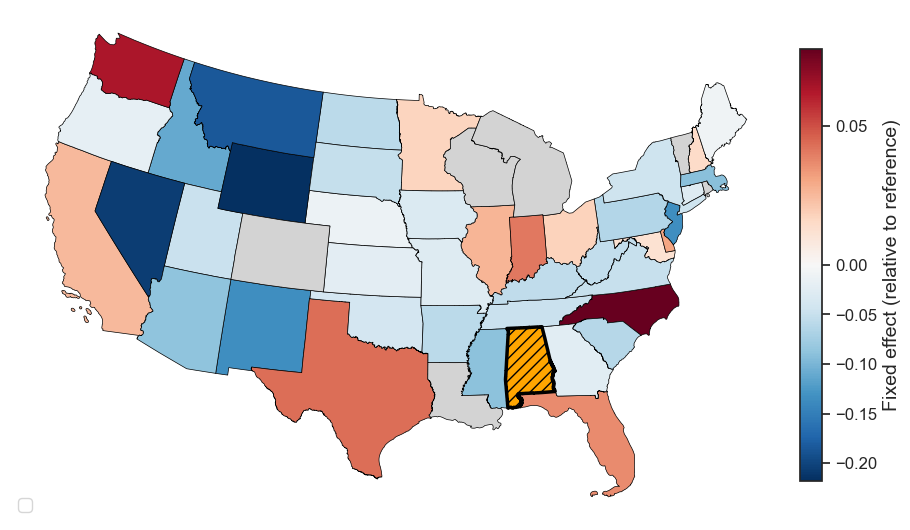

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Base map: fixed effects
states_fe.plot(
    column="coef_plot",
    cmap="RdBu_r",
    norm =  mcolors.TwoSlopeNorm(
    vmin=states_fe["coef_plot"].min(),
    vcenter=0,
    vmax=states_fe["coef_plot"].max()
),
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "shrink": 0.7,      # <<< KEY LINE (reduce height)
        "aspect": 20,       # thinner bar
        "pad": 0.02,
        "label": "Fixed effect (relative to reference)"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Not statistically significant"
    }
)

# Overlay reference state with thick black outline
states_fe.loc[states_fe["STATEFP"] == ref_state].plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=2.5,
    hatch="///",          # optional but very clear
    # label="Reference state"
)

# ax.set_title("Source-state fixed effects (reference state highlighted)")
ax.axis("off")

# Legend fix (GeoPandas doesn't auto-handle overlays well)
ax.legend(loc="lower left")

# plt.savefig('models/{}/evaluations/figures/CPC_state_fixed_effcts.pdf'.format(model), bbox_inches='tight')

plt.show()

In [ ]:
import statsmodels.formula.api as smf

df_analysis_copy = df_analysis.copy()
df_analysis_copy['log_rmse'] = df_analysis_copy['RMSE'].apply(np.log1p)
feat_scaler = StandardScaler()

predictors = ['mi_shift', 'moran_shift']
df_analysis_copy[predictors] = feat_scaler.fit_transform(df_analysis_copy[predictors])

m = smf.mixedlm(
    "log_rmse~ mi_shift + moran_shift + C(src_state, Treatment(reference='01'))",
    # "CPC ~ mi_shift + moran_shift ",
    data=df_analysis_copy,
    groups=df_analysis["tar_geoid"],
    # vc_formula={"train_state": "0 + C(src_state)"}
).fit(reml=True)

print(m.summary())


                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_rmse  
No. Observations:            105845             Method:                        REML      
No. Groups:                  2252               Scale:                         0.0147    
Min. group size:             47                 Log-Likelihood:                64629.7054
Max. group size:             48                 Converged:                     Yes       
Mean group size:             47.0                                                        
-----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      4.143    0.014 286.206 0.000  4.114  4.171
C(src_state, Treatment(reference='01

In [ ]:
import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

def joint_partial_heatmap(
    df,
    result,
    mi_col="mi_shift",
    moran_col="moran_shift",
    state_col="src_state",
    rhs="C(src_state) + mi_shift + moran_shift",  # MUST match your MixedLM fixed-effects RHS
    n_grid=60,
    use_state="mode",   # "mode" or specify a value like "CA" / 04 etc.
    q_low=0.05,
    q_high=0.95,
    cmap="viridis_r"
):
    # --- 1) Choose ranges (avoid extreme tails) ---
    mi_grid = np.linspace(df[mi_col].quantile(q_low), df[mi_col].quantile(q_high), n_grid)
    moran_grid = np.linspace(df[moran_col].quantile(q_low), df[moran_col].quantile(q_high), n_grid)
    MI, MORAN = np.meshgrid(mi_grid, moran_grid)

    # --- 2) Pick a reference training state for the fixed effects ---
    if use_state == "mode":
        ref_state = df[state_col].mode()[0]
    else:
        ref_state = use_state

    # Force category levels to match training data (important for C(src_state))
    src_cats = pd.Categorical(df[state_col]).categories

    pred_df = pd.DataFrame({
        mi_col: MI.ravel(),
        moran_col: MORAN.ravel(),
        state_col: pd.Categorical([ref_state] * MI.size, categories=src_cats)
    })

    # --- 3) Build X using the SAME columns as the fitted model ---
    X_pred = patsy.dmatrix(rhs, pred_df, return_type="dataframe")

    beta = result.fe_params  # pandas Series
    X_pred = X_pred.reindex(columns=beta.index, fill_value=0.0)  # align exactly

    Z = (X_pred.to_numpy() @ beta.to_numpy()).reshape(MI.shape)

    # --- 4) Plot (heatmap style) ---
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        Z,
        cmap=cmap,
        cbar_kws={"label": "Predicted Log of RMSE (fixed effects only)"}
    )

    # Make axes readable (don’t label every grid point)
    xticks = np.linspace(0, n_grid - 1, 6).astype(int)
    yticks = np.linspace(0, n_grid - 1, 6).astype(int)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([f"{mi_grid[i]:.2f}" for i in xticks], rotation=0)
    ax.set_yticklabels([f"{moran_grid[i]:.2f}" for i in yticks], rotation=0)

    ax.set_xlabel("MI Shift")
    ax.set_ylabel("Moran Shift")
    # ax.set_title("Joint partial effect of MI Shift and Moran Shift (MixedLM)")

    ax.invert_yaxis()
    plt.tight_layout()


    # plt.savefig('models/{}/evaluations/figures/Joint_partial_effects_RMSE.pdf'.format(model), bbox_inches='tight')

    plt.show()

    return MI, MORAN, Z

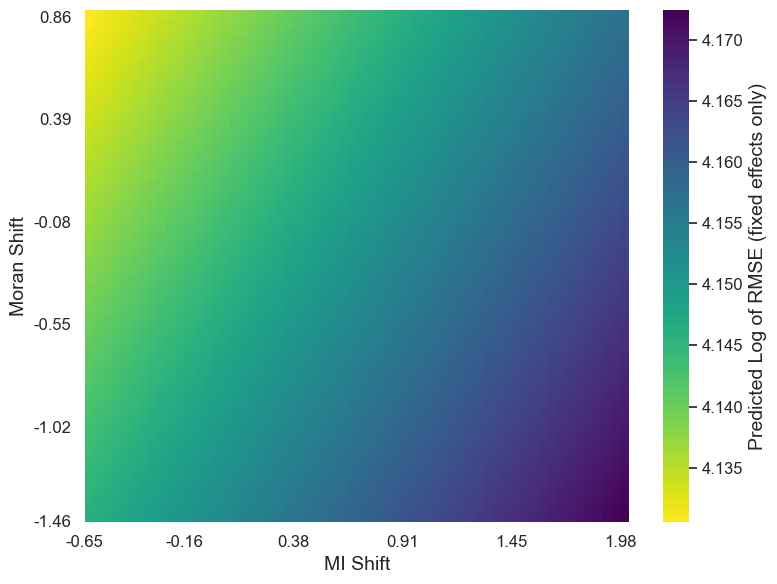

In [ ]:
MI, MORAN, Z = joint_partial_heatmap(df_analysis_copy, m)

In [ ]:
import pandas as pd
import numpy as np

fe = m.fe_params
se = m.bse_fe

state_terms = fe.index[fe.index.str.startswith("C(src_state, Treatment(reference='01'))[T.")]
df_state = pd.DataFrame({
    "term": state_terms,
    "coef": fe.loc[state_terms].values,
    "se": se.loc[state_terms].values
})

# Extract FIPS code
df_state["state_fips"] = df_state["term"].str.extract(r"\[T\.(.*)\]")


In [ ]:
states_fe = gpd_us_state.merge(
    df_state,
    left_on="STATEFP",
    right_on="state_fips",
    how="left"
)

states_fe["sig"] = states_fe["coef"].abs() > 1.96 * states_fe["se"]
# states_fe.loc[~states_fe["sig"], "coef"] = 0.0
states_fe["coef_plot"] = states_fe["coef"]
states_fe.loc[~states_fe["sig"], "coef_plot"] = np.nan

/tmp/ipython-input-3226481400.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")
/tmp/ipython-input-3226481400.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


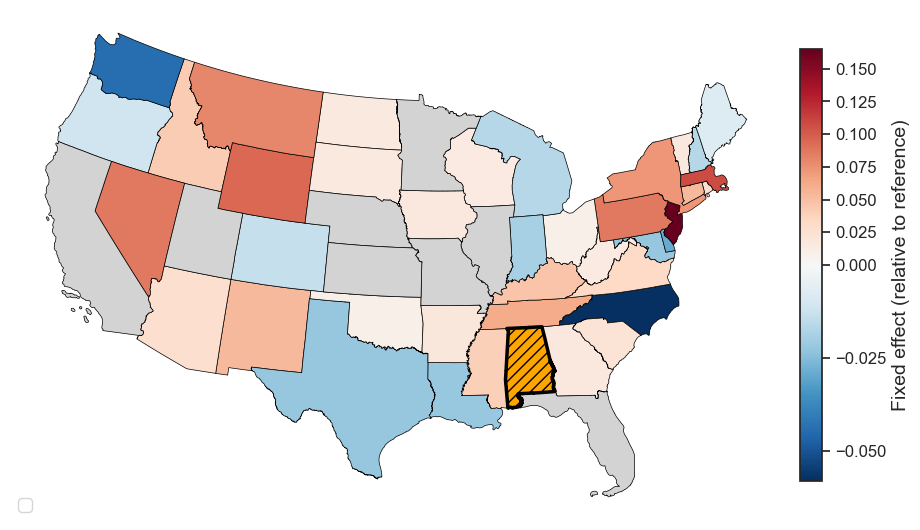

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Base map: fixed effects
states_fe.plot(
    column="coef_plot",
    norm =  mcolors.TwoSlopeNorm(
    vmin=states_fe["coef_plot"].min(),
    vcenter=0,
    vmax=states_fe["coef_plot"].max()
),
    cmap="RdBu_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "shrink": 0.7,      # <<< KEY LINE (reduce height)
        "aspect": 20,       # thinner bar
        "pad": 0.02,
        "label": "Fixed effect (relative to reference)"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Not statistically significant"
    }
)

# Overlay reference state with thick black outline
states_fe.loc[states_fe["STATEFP"] == ref_state].plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=2.5,
    hatch="///",          # optional but very clear
    # label="Reference state"
)

# ax.set_title("Source-state fixed effects (reference state highlighted)")
ax.axis("off")

# Legend fix (GeoPandas doesn't auto-handle overlays well)
ax.legend(loc="lower left")

# plt.savefig('models/{}/evaluations/figures/RMSE_state_fixed_effcts.pdf'.format(model), bbox_inches='tight')

plt.show()

### **Tabel 3: Dataset size and transferability**

In [ ]:
df_analysis_agg_src = df_analysis.copy()
df_analysis_agg_src['RMSE'] = df_analysis_agg_src['RMSE'].apply(np.log1p)
# df_analysis_agg_src = df_analysis_agg_src.drop(columns = ['num_regions', 'tar_geoid' ]).groupby('src_state').agg(['mean'])
df_analysis_agg_src = df_analysis_agg_src.drop(columns = ['num_regions', 'tar_geoid', 'tar_state']).groupby('src_state').agg(['mean'])
df_analysis_agg_src.columns = ['_'.join(col) for col in df_analysis_agg_src.columns]

In [ ]:
df_state_ct_count = pd.read_csv('models/{}/evaluations/tables/dataset_statistics/county_census_tract_count.csv'.format(model), dtype={'GEOID': str})

In [ ]:
df_analysis_agg_src.head()

,RMSE_mean,NRMSE_mean,MAE_mean,MAPE_mean,SMAPE_mean,CPC_mean,RMSE_nonzero_mean,MAE_nonzero_mean,MAPE_nonzero_mean,SMAPE_nonzero_mean,...,matrix_COS_similarity_mean,JSD_inflow_mean,JSD_outflow_mean,JSD_ODflow_mean,mi_shift_mean,moran_dis_mean,src_moran_mean,tar_moran_mean,moran_shift_mean,moran_mean_mean
src_state,,,,,,,,,,,,,,,,,,,,,
01,4.141913,0.833881,51.118395,2.741840,0.893495,0.634275,79.188146,52.586789,1.885903,0.795621,...,0.801156,0.204184,0.232790,0.118245,0.003365,1.006194,-0.138971,-0.127155,0.096576,0.011816
04,4.171755,0.838469,50.963014,3.173686,0.908026,0.615201,80.445252,52.189777,2.104402,0.811009,...,0.793854,0.297714,0.249935,0.220710,0.003520,1.342070,-0.047259,-0.127946,-1.111373,-0.080687
05,4.150411,0.835313,50.692869,2.927977,0.910422,0.621119,79.335411,52.094975,1.981085,0.811619,...,0.793038,0.258576,0.236865,0.157563,0.005533,1.022791,-0.216922,-0.125158,0.611809,0.091764
06,4.150963,0.839102,50.209227,2.243248,0.862633,0.641990,80.733145,51.709415,1.550973,0.765010,...,0.809550,0.232570,0.190443,0.115916,0.000775,1.081699,-0.047778,-0.129438,-0.902422,-0.081660
08,4.121597,0.823397,49.585472,2.705505,0.887385,0.636443,77.893215,50.945877,1.820454,0.788917,...,0.808390,0.234655,0.216905,0.133861,0.003377,1.121652,-0.127675,-0.127477,0.001504,0.000198


In [ ]:
df_state_ct_count['src_state'] = df_state_ct_count['GEOID'].str[:2]

In [ ]:
df_state_ct_count_agg = df_state_ct_count.drop(columns = ['GEOID' ]).groupby('src_state').agg(['sum'])
df_state_ct_count_agg.columns = ['_'.join(col) for col in df_state_ct_count_agg.columns]

In [ ]:
df_state_ct_count_agg.columns

Index(['count_sum'], dtype='object')

In [ ]:
df_state_ct_count_agg = df_state_ct_count_agg.rename(columns={('count_sum'): 'ct_count'})

In [ ]:
df_analysis_agg_src_ct = df_analysis_agg_src.merge(df_state_ct_count_agg, left_index = True, right_index = True, how = 'left')

In [ ]:
df_analysis_agg_src_ct.head()

,RMSE_mean,NRMSE_mean,MAE_mean,MAPE_mean,SMAPE_mean,CPC_mean,RMSE_nonzero_mean,MAE_nonzero_mean,MAPE_nonzero_mean,SMAPE_nonzero_mean,...,JSD_inflow_mean,JSD_outflow_mean,JSD_ODflow_mean,mi_shift_mean,moran_dis_mean,src_moran_mean,tar_moran_mean,moran_shift_mean,moran_mean_mean,ct_count
src_state,,,,,,,,,,,,,,,,,,,,,
01,4.141913,0.833881,51.118395,2.741840,0.893495,0.634275,79.188146,52.586789,1.885903,0.795621,...,0.204184,0.232790,0.118245,0.003365,1.006194,-0.138971,-0.127155,0.096576,0.011816,1165
04,4.171755,0.838469,50.963014,3.173686,0.908026,0.615201,80.445252,52.189777,2.104402,0.811009,...,0.297714,0.249935,0.220710,0.003520,1.342070,-0.047259,-0.127946,-1.111373,-0.080687,1282
05,4.150411,0.835313,50.692869,2.927977,0.910422,0.621119,79.335411,52.094975,1.981085,0.811619,...,0.258576,0.236865,0.157563,0.005533,1.022791,-0.216922,-0.125158,0.611809,0.091764,638
06,4.150963,0.839102,50.209227,2.243248,0.862633,0.641990,80.733145,51.709415,1.550973,0.765010,...,0.232570,0.190443,0.115916,0.000775,1.081699,-0.047778,-0.129438,-0.902422,-0.081660,5694
08,4.121597,0.823397,49.585472,2.705505,0.887385,0.636443,77.893215,50.945877,1.820454,0.788917,...,0.234655,0.216905,0.133861,0.003377,1.121652,-0.127675,-0.127477,0.001504,0.000198,1202


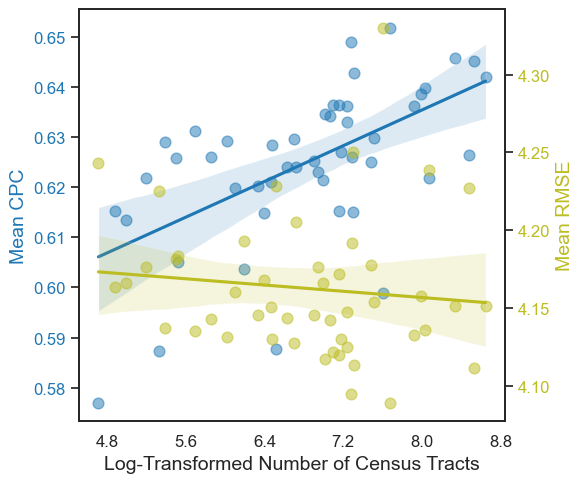

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("whitegrid", {
#     "grid.linestyle": "--",
#     "grid.alpha": 0.3
# })
# sns.set_context("paper")
# Dual Y-axis plot
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot RMSE on the left axis
color = 'tab:blue'
ax1.set_ylabel('RMSE', color=color)
sns.regplot(x=df_analysis_agg_src_ct['ct_count'].apply(np.log1p), y=df_analysis_agg_src_ct['CPC_mean'], ax=ax1, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('Log-Transformed Number of Census Tracts')
ax1.set_ylabel('Mean CPC')
# ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1e}"))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))

# Create a second axis for CPC sharing the same x-axis
ax2 = ax1.twinx()
color = 'tab:olive'
ax2.set_ylabel('CPC', color=color)
sns.regplot(x=df_analysis_agg_src_ct['ct_count'].apply(np.log1p), y=df_analysis_agg_src_ct['RMSE_mean'], ax=ax2, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Mean RMSE')

# plt.title('MI Shift vs RMSE and CPC')
plt.tight_layout()

# plt.savefig('models/{}/evaluations/figures/dataset_size_effect.pdf'.format(model))
plt.show()


In [ ]:
from scipy.stats import spearmanr, pearsonr
# 1. Pearson correlation
# r_rmse, p_rmse = pearsonr(df_analysis_agg_src_ct['ct_count'].apply(np.log1p), df_analysis_agg_src_ct['RMSE_mean'])
# r_cpc,  p_cpc  = pearsonr(df_analysis_agg_src_ct['ct_count'].apply(np.log1p), df_analysis_agg_src_ct['CPC_mean'])

# r_rmse, p_rmse = pearsonr(df_analysis_agg_src_ct['moran_shift_mean'], df_analysis_agg_src_ct['RMSE_mean'])
# r_cpc,  p_cpc  = pearsonr(df_analysis_agg_src_ct['moran_shift_mean'], df_analysis_agg_src_ct['CPC_mean'])

r_rmse, p_rmse = pearsonr(df_analysis_agg_src_ct['ct_count'].apply(np.log1p), df_analysis_agg_src_ct['RMSE_mean'])
r_cpc,  p_cpc  = pearsonr(df_analysis_agg_src_ct['ct_count'].apply(np.log1p), df_analysis_agg_src_ct['CPC_mean'])

print("Pearson correlation shift–RMSE:", r_rmse, "p=", p_rmse)
print("Pearson correlation shift–CPC: ", r_cpc,  "p=", p_cpc)

Pearson correlation shift–RMSE: -0.11083016187441182 p= 0.45329788001010973
Pearson correlation shift–CPC:  0.5779771191489269 p= 1.693608446290417e-05


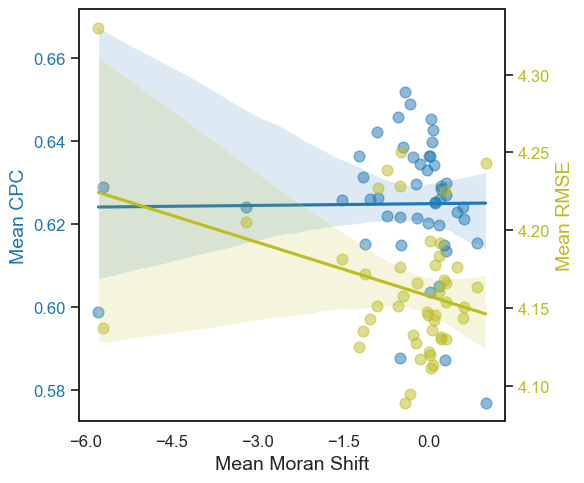

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("whitegrid", {
#     "grid.linestyle": "--",
#     "grid.alpha": 0.3
# })
# sns.set_context("paper")
# Dual Y-axis plot
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot RMSE on the left axis
color = 'tab:blue'
ax1.set_ylabel('RMSE', color=color)
sns.regplot(x=df_analysis_agg_src_ct['moran_shift_mean'], y=df_analysis_agg_src_ct['CPC_mean'], ax=ax1, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('Mean Moran Shift')
ax1.set_ylabel('Mean CPC')
# ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1e}"))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))

# Create a second axis for CPC sharing the same x-axis
ax2 = ax1.twinx()
color = 'tab:olive'
ax2.set_ylabel('CPC', color=color)
sns.regplot(x=df_analysis_agg_src_ct['moran_shift_mean'], y=df_analysis_agg_src_ct['RMSE_mean'], ax=ax2, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Mean RMSE')

# plt.title('MI Shift vs RMSE and CPC')
plt.tight_layout()

# plt.savefig('models/{}/evaluations/figures/moran_shift_effect.pdf'.format(model))
plt.show()


In [ ]:
from scipy.stats import spearmanr, pearsonr
# 1. Pearson correlation

r_rmse, p_rmse = pearsonr(df_analysis_agg_src_ct['moran_shift_mean'], df_analysis_agg_src_ct['RMSE_mean'])
r_cpc,  p_cpc  = pearsonr(df_analysis_agg_src_ct['moran_shift_mean'], df_analysis_agg_src_ct['CPC_mean'])


print("Pearson correlation shift–RMSE:", r_rmse, "p=", p_rmse)
print("Pearson correlation shift–CPC: ", r_cpc,  "p=", p_cpc)

Pearson correlation shift–RMSE: -0.33358347925027304 p= 0.02050275651252016
Pearson correlation shift–CPC:  0.01188168095401085 p= 0.9361167054847503


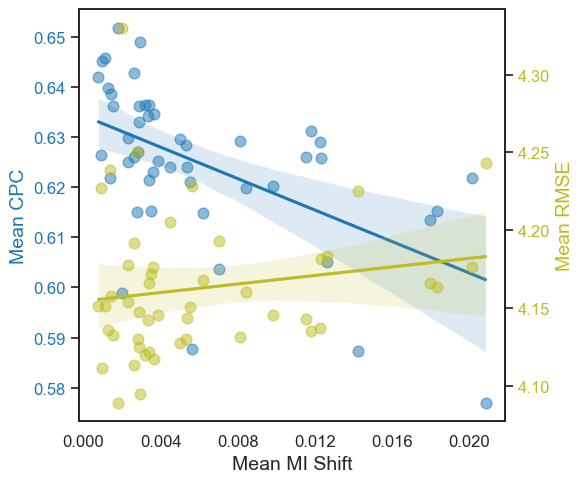

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 14,
    "pdf.fonttype": 42,
})

from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("whitegrid", {
#     "grid.linestyle": "--",
#     "grid.alpha": 0.3
# })
# sns.set_context("paper")
# Dual Y-axis plot
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot RMSE on the left axis
color = 'tab:blue'
ax1.set_ylabel('RMSE', color=color)
sns.regplot(x=df_analysis_agg_src_ct['mi_shift_mean'], y=df_analysis_agg_src_ct['CPC_mean'], ax=ax1, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('Mean MI Shift')
ax1.set_ylabel('Mean CPC')
# ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1e}"))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))

# Create a second axis for CPC sharing the same x-axis
ax2 = ax1.twinx()
color = 'tab:olive'
ax2.set_ylabel('CPC', color=color)
sns.regplot(x=df_analysis_agg_src_ct['mi_shift_mean'], y=df_analysis_agg_src_ct['RMSE_mean'], ax=ax2, color=color, scatter_kws={'alpha': 0.5, 's': 60})
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Mean RMSE')

# plt.title('MI Shift vs RMSE and CPC')
plt.tight_layout()

# plt.savefig('models/{}/evaluations/figures/mi_shift_effect.pdf'.format(model))
plt.show()


In [ ]:
from scipy.stats import spearmanr, pearsonr
# 1. Pearson correlation

r_rmse, p_rmse = pearsonr(df_analysis_agg_src_ct['mi_shift_mean'], df_analysis_agg_src_ct['RMSE_mean'])
r_cpc,  p_cpc  = pearsonr(df_analysis_agg_src_ct['mi_shift_mean'], df_analysis_agg_src_ct['CPC_mean'])


print("Pearson correlation shift–RMSE:", r_rmse, "p=", p_rmse)
print("Pearson correlation shift–CPC: ", r_cpc,  "p=", p_cpc)

Pearson correlation shift–RMSE: 0.01996974873789534 p= 0.8928325933277987
Pearson correlation shift–CPC:  -0.5469071704919886 p= 5.769151769404274e-05


In [ ]:
import statsmodels.api as sm

# y = df_analysis_agg_src_ct['CPC_mean']
y = np.log(df_analysis_agg_src_ct['CPC_mean'] / (1 - df_analysis_agg_src_ct['CPC_mean']))
X_full = df_analysis_agg_src_ct[['ct_count', 'mi_shift_mean','moran_shift_mean' ]]
X_full = feat_scaler.fit_transform(X_full)
X_full = sm.add_constant(X_full)
m_full = sm.OLS(y, X_full).fit()

# reduced (drop MI)
X_no_mi = sm.add_constant(df_analysis_agg_src_ct[['moran_shift_mean', 'ct_count']])
m_no_mi = sm.OLS(y, X_no_mi).fit()

# reduced (drop Moran)
X_no_moran = sm.add_constant(df_analysis_agg_src_ct[['mi_shift_mean', 'ct_count']])
m_no_moran = sm.OLS(y, X_no_moran).fit()

# reduced (drop ct_count)
X_no_count = sm.add_constant(df_analysis_agg_src_ct[['moran_shift_mean','mi_shift_mean',]])
m_no_count = sm.OLS(y, X_no_count).fit()

def partial_r2(r2_full, r2_reduced):
    return (r2_full - r2_reduced) / (1 - r2_reduced)

pr2_mi    = partial_r2(m_full.rsquared, m_no_mi.rsquared)      # unique MI
pr2_moran = partial_r2(m_full.rsquared, m_no_moran.rsquared)   # unique Moran
pr2_count = partial_r2(m_full.rsquared, m_no_count.rsquared)   # unique Moran

pr2_mi, pr2_moran, pr2_count

(np.float64(0.12122753671092311),
 np.float64(0.004066772283707942),
 np.float64(0.04224724309092749))

In [ ]:
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:               CPC_mean   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     7.261
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           0.000464
Time:                        01:09:43   Log-Likelihood:                 72.774
No. Observations:                  48   AIC:                            -137.5
Df Residuals:                      44   BIC:                            -130.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5105      0.008     63.744      0.0

In [ ]:
import statsmodels.api as sm

y = df_analysis_agg_src_ct['RMSE_mean']
# y = np.log(df_analysis_agg_src_ct['CPC_mean'] / (1 - df_analysis_agg_src_ct['CPC_mean']))
X_full = df_analysis_agg_src_ct[['ct_count', 'mi_shift_mean','moran_shift_mean']]
X_full = feat_scaler.fit_transform(X_full)
X_full = sm.add_constant(X_full)
m_full = sm.OLS(y, X_full).fit()

# reduced (drop MI)
X_no_mi = sm.add_constant(df_analysis_agg_src_ct[['moran_shift_mean', 'ct_count']])
m_no_mi = sm.OLS(y, X_no_mi).fit()

# reduced (drop Moran)
X_no_moran = sm.add_constant(df_analysis_agg_src_ct[['mi_shift_mean', 'ct_count']])
m_no_moran = sm.OLS(y, X_no_moran).fit()

# reduced (drop ct_count)
X_no_count = sm.add_constant(df_analysis_agg_src_ct[['moran_shift_mean','mi_shift_mean',]])
m_no_count = sm.OLS(y, X_no_count).fit()

def partial_r2(r2_full, r2_reduced):
    return (r2_full - r2_reduced) / (1 - r2_reduced)

pr2_mi    = partial_r2(m_full.rsquared, m_no_mi.rsquared)      # unique MI
pr2_moran = partial_r2(m_full.rsquared, m_no_moran.rsquared)   # unique Moran
pr2_count = partial_r2(m_full.rsquared, m_no_count.rsquared)   # unique Moran

pr2_mi, pr2_moran, pr2_count

(np.float64(0.04599900989941078),
 np.float64(0.12132236100860538),
 np.float64(0.010596621107532124))

In [ ]:
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:              RMSE_mean   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     2.678
Date:                Wed, 29 Apr 2026   Prob (F-statistic):             0.0586
Time:                        01:13:33   Log-Likelihood:                 84.669
No. Observations:                  48   AIC:                            -161.3
Df Residuals:                      44   BIC:                            -153.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1626      0.006    665.890      0.0